# Titanic — Machine Learning from Disaster

**Goal:** Predict which passengers survived the Titanic sinking (binary: 0 = died, 1 = survived).

**Metric:** Accuracy (% of correct predictions on the test set).

**Baseline to beat:** ~76% (predict all women survive, all men die — see `gender_submission.csv`).

---
## Phase 0 — Setup

Import libraries and load data. The path auto-detects whether we're running locally or on Kaggle.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

%matplotlib inline
sns.set_theme(style="whitegrid")

# Auto-detect: Kaggle vs local
DATA_DIR = '/kaggle/input/titanic' if os.path.exists('/kaggle/input/titanic') else 'dataset'

train = pd.read_csv(f'{DATA_DIR}/train.csv')
test  = pd.read_csv(f'{DATA_DIR}/test.csv')

print(f'Train: {train.shape}  |  Test: {test.shape}')

Train: (891, 12)  |  Test: (418, 11)


---
## Phase 1 — Explore the Data (EDA)

Understand the dataset before touching anything.

**Questions to answer:**
- What are the column types and shapes?
- Which columns have missing values and how many?
- What is the overall survival rate?
- How does survival vary by Sex, Pclass, Age, and Embarked?
- What does the Fare distribution look like?
- Are there correlations between numeric features?

In [2]:
# First look at the raw data
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Column types and non-null counts
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
# Missing value audit — how many gaps and what % of each dataset
def missing_report(df, name):
    m = df.isnull().sum()
    m = m[m > 0].sort_values(ascending=False)
    pct = (m / len(df) * 100).round(1)
    return pd.DataFrame({'Missing': m, '%': pct}).rename_axis(name)

print(missing_report(train, 'TRAIN'))
print()
print(missing_report(test, 'TEST'))

          Missing     %
TRAIN                  
Cabin         687  77.1
Age           177  19.9
Embarked        2   0.2

       Missing     %
TEST                
Cabin      327  78.2
Age         86  20.6
Fare         1   0.2


In [5]:
# Overall survival rate and breakdown by the strongest features
print(f"Overall survival rate: {train['Survived'].mean():.1%}\n")

for col in ['Sex', 'Pclass', 'Embarked']:
    rates = train.groupby(col)['Survived'].agg(['mean', 'count'])
    rates.columns = ['Survival Rate', 'Count']
    rates['Survival Rate'] = rates['Survival Rate'].map('{:.1%}'.format)
    print(f'--- By {col} ---')
    print(rates, '\n')

Overall survival rate: 38.4%

--- By Sex ---
       Survival Rate  Count
Sex                        
female         74.2%    314
male           18.9%    577 

--- By Pclass ---
       Survival Rate  Count
Pclass                     
1              63.0%    216
2              47.3%    184
3              24.2%    491 

--- By Embarked ---
         Survival Rate  Count
Embarked                     
C                55.4%    168
Q                39.0%     77
S                33.7%    644 



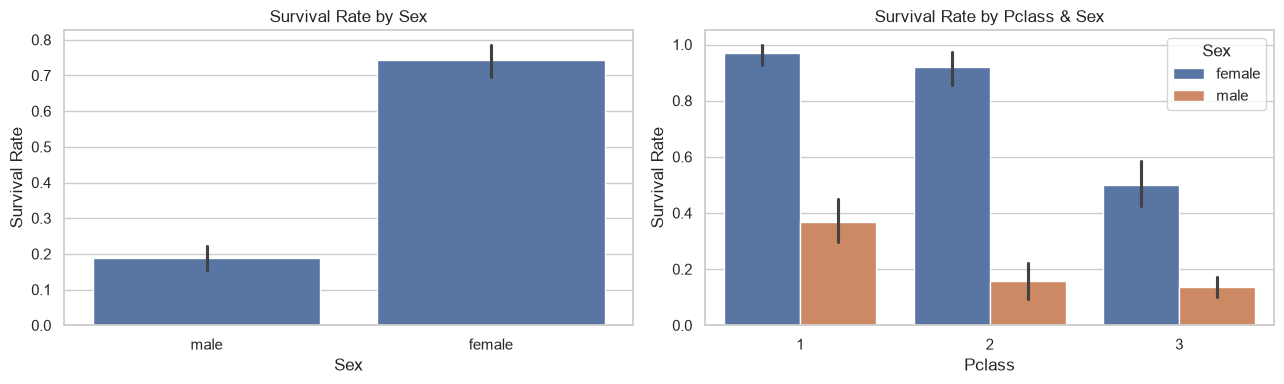

In [6]:
# Visualise survival by Sex and Pclass together
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=train, x='Sex', y='Survived', ax=axes[0])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')

sns.barplot(data=train, x='Pclass', y='Survived', hue='Sex', ax=axes[1])
axes[1].set_title('Survival Rate by Pclass & Sex')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

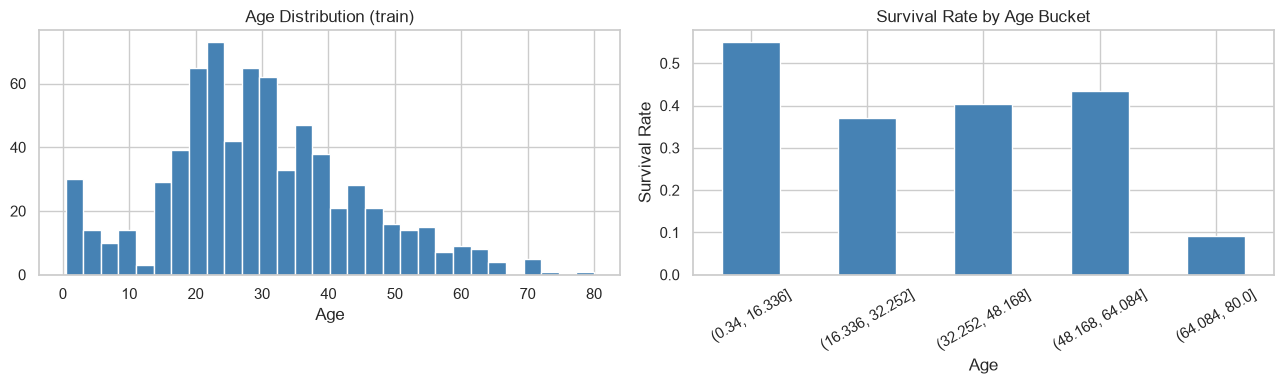

In [7]:
# Age: distribution and survival rate across age buckets
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

train['Age'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution (train)')
axes[0].set_xlabel('Age')

age_buckets = pd.cut(train['Age'], bins=5)
train.groupby(age_buckets)['Survived'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Survival Rate by Age Bucket')
axes[1].set_ylabel('Survival Rate')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

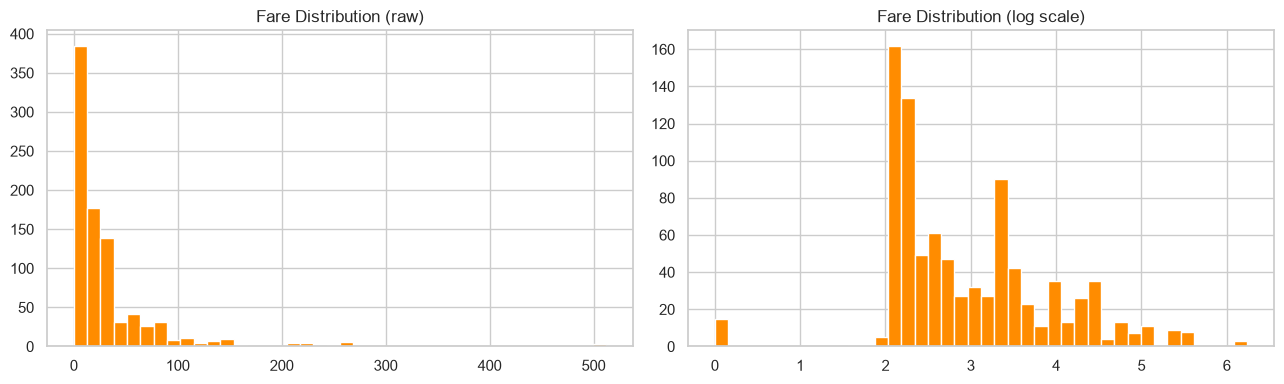

In [8]:
# Fare: raw vs log-transformed (Fare is heavily right-skewed)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

train['Fare'].hist(bins=40, ax=axes[0], color='darkorange', edgecolor='white')
axes[0].set_title('Fare Distribution (raw)')

np.log1p(train['Fare']).hist(bins=40, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Fare Distribution (log scale)')

plt.tight_layout()
plt.show()

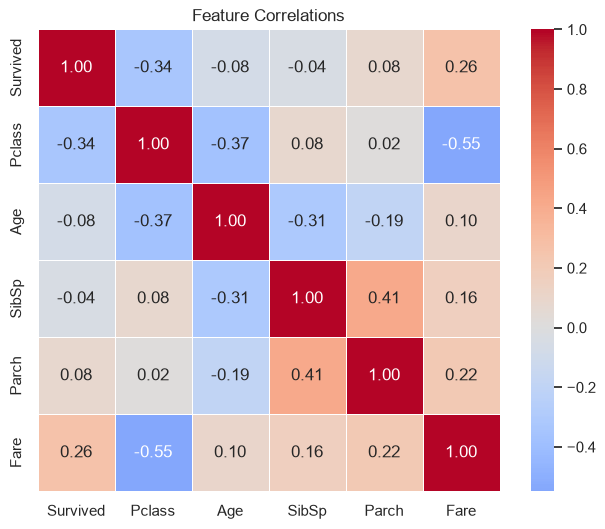

In [9]:
# Correlation heatmap — numeric features only
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

plt.figure(figsize=(8, 6))
sns.heatmap(
    train[numeric_cols].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Feature Correlations')
plt.show()

---
## Phase 2 — Clean & Handle Missing Values

Fix the gaps so every column is usable.

| Column | Strategy |
|---|---|
| `Age` | Median imputed per `Pclass` + `Sex` group |
| `Embarked` | Fill 2 missing rows with mode (`'S'`) |
| `Fare` | Fill 1 missing row in test with median of same `Pclass` |
| `Cabin` | Too sparse (77% missing) — convert to `HasCabin` flag, drop raw column |
| `Ticket` | No predictive value — drop |
| `Name` | Keep for now — we extract Title from it in Phase 3, then drop |

In [10]:
# Work on copies — keep originals intact for reference
train_df = train.copy()
test_df  = test.copy()

# --- Age: group median (Pclass + Sex) — a 3rd-class man gets a different fill than a 1st-class woman
age_medians = train_df.groupby(['Pclass', 'Sex'])['Age'].median()

def fill_age(row):
    if pd.isnull(row['Age']):
        return age_medians.loc[(row['Pclass'], row['Sex'])]
    return row['Age']

train_df['Age'] = train_df.apply(fill_age, axis=1)
test_df['Age']  = test_df.apply(fill_age, axis=1)

# --- Embarked: 2 missing in train → fill with mode
embarked_mode = train_df['Embarked'].mode()[0]
train_df['Embarked'] = train_df['Embarked'].fillna(embarked_mode)

# --- Fare: 1 missing in test → median of same Pclass from train
fare_medians = train_df.groupby('Pclass')['Fare'].median()
test_df['Fare'] = test_df.apply(
    lambda row: fare_medians[row['Pclass']] if pd.isnull(row['Fare']) else row['Fare'],
    axis=1
)

# --- Cabin: create binary flag then drop the raw column
for df in [train_df, test_df]:
    df['HasCabin'] = df['Cabin'].notna().astype(int)

# --- Drop columns with no usable signal
train_df.drop(columns=['Cabin', 'Ticket'], inplace=True)
test_df.drop(columns=['Cabin', 'Ticket'],  inplace=True)

# Verify: nothing missing except Name (intentional — needed in Phase 3)
print('Remaining missing — Train:')
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])
print('\nRemaining missing — Test:')
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])

Remaining missing — Train:
Series([], dtype: int64)

Remaining missing — Test:
Series([], dtype: int64)


---
## Phase 3 — Feature Engineering

Create new columns that better capture what drove survival.

| Feature | How |
|---|---|
| `Title` | Regex extract from `Name` → Mr / Mrs / Miss / Master / Rare |
| `FamilySize` | `SibSp + Parch + 1` |
| `IsAlone` | 1 if `FamilySize == 1` |
| `AgeBand` | Bin `Age` into 5 ordinal buckets |
| `FareBand` | Bin `Fare` into 4 quartile buckets |

Then encode all categoricals to numbers so models can use them.

In [11]:
# Title extraction — the Name column holds 'Last, Title. First' format
# Master = young boy (huge survival signal among males)

TITLE_MAP = {
    'Mr': 'Mr', 'Mrs': 'Mrs', 'Miss': 'Miss', 'Master': 'Master',
    'Mlle': 'Miss', 'Ms': 'Mrs', 'Mme': 'Mrs',       # common aliases
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare',       # rare titles
    'Major': 'Rare', 'Capt': 'Rare', 'Sir': 'Rare',
    'Lady': 'Rare', 'Countess': 'Rare', 'Don': 'Rare',
    'Dona': 'Rare', 'Jonkheer': 'Rare',
}

def extract_title(name):
    match = re.search(r' ([A-Za-z]+)\.', name)
    raw = match.group(1) if match else 'Unknown'
    return TITLE_MAP.get(raw, 'Rare')

for df in [train_df, test_df]:
    df['Title'] = df['Name'].apply(extract_title)

# Sanity check: survival rate by Title (should show Master and female titles above 0.5)
print(train_df.groupby('Title')['Survived'].agg(['mean', 'count']).rename(columns={'mean': 'Survival Rate', 'count': 'Count'}))

        Survival Rate  Count
Title                       
Master       0.575000     40
Miss         0.701087    184
Mr           0.156673    517
Mrs          0.795276    127
Rare         0.347826     23


In [ ]:
# Family features and binned Age/Fare
#
# IMPORTANT: bin edges must be computed from TRAIN only, then applied to test.
# If we call pd.cut/pd.qcut separately on each df, the edges differ —
# FareBand=2 in train means a different fare range than FareBand=2 in test,
# so the model learns the wrong mapping.

for df in [train_df, test_df]:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']    = (df['FamilySize'] == 1).astype(int)

# Compute bin edges from train, reuse for test
_, age_bins  = pd.cut(train_df['Age'],  bins=5, retbins=True)
_, fare_bins = pd.qcut(train_df['Fare'], q=4, retbins=True, duplicates='drop')

for df in [train_df, test_df]:
    df['AgeBand']  = pd.cut(df['Age'],  bins=age_bins,  labels=False, include_lowest=True)
    df['FareBand'] = pd.cut(df['Fare'], bins=fare_bins, labels=False, include_lowest=True)

# Fill any NaN in AgeBand/FareBand (test values outside train range → nearest bucket)
for df in [train_df, test_df]:
    df['AgeBand']  = df['AgeBand'].fillna(0).astype(int)
    df['FareBand'] = df['FareBand'].fillna(0).astype(int)

# Sanity check
print('Survival by FamilySize:')
print(train_df.groupby('FamilySize')['Survived'].mean().round(3))
print(f'\nAgeBand values  in train: {sorted(train_df["AgeBand"].unique())}')
print(f'AgeBand values  in test : {sorted(test_df["AgeBand"].unique())}')
print(f'FareBand values in train: {sorted(train_df["FareBand"].unique())}')
print(f'FareBand values in test : {sorted(test_df["FareBand"].unique())}')

In [ ]:
# Drop Name — done extracting from it
# Also drop SibSp/Parch (captured by FamilySize/IsAlone) and the band columns
# (Age/Fare raw values carry more info and avoid the train/test bin edge mismatch)
train_df.drop(columns=['Name', 'SibSp', 'Parch', 'AgeBand', 'FareBand'], inplace=True)
test_df.drop(columns=['Name',  'SibSp', 'Parch', 'AgeBand', 'FareBand'], inplace=True)

# Log-transform Fare — it's heavily right-skewed, log makes it more useful for linear models
# and reduces the influence of extreme outliers on tree splits
train_df['Fare'] = np.log1p(train_df['Fare'])
test_df['Fare']  = np.log1p(test_df['Fare'])

# Encode categoricals: fit on combined train+test so both sets share the same integer mapping
cat_cols = ['Sex', 'Embarked', 'Title']
le = LabelEncoder()

for col in cat_cols:
    combined = pd.concat([train_df[col], test_df[col]], ignore_index=True)
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

# Final feature set
print('Final columns:', train_df.columns.tolist())
print(f'\nShape — Train: {train_df.shape}  Test: {test_df.shape}')
train_df.head()

---
## Phase 4 — Modeling

Train a ladder of models, simplest first.

1. **Logistic Regression** — interpretable baseline
2. **Random Forest** — captures non-linear feature interactions
3. **XGBoost / LightGBM** — usually best single model on tabular data
4. **Voting Ensemble** — soft vote of top models if CV scores are close

After each tree model: check feature importances to confirm engineered features are contributing.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# Cleaner feature set — no redundant columns, no binned versions
FEATURES = [
    'Pclass', 'Sex', 'Age', 'Fare', 'Embarked',
    'HasCabin', 'Title', 'FamilySize', 'IsAlone'
]

X      = train_df[FEATURES]
y      = train_df['Survived']
X_test = test_df[FEATURES]

print(f'X (train features) : {X.shape}')
print(f'X_test             : {X_test.shape}')
print(f'\nFeatures: {FEATURES}')

In [ ]:
# --- Model 1: Logistic Regression ---
# Simplest possible model. Learns a weight for each feature and adds them up.
# Positive weight = pushes prediction toward "survived", negative = toward "died".
# Good for understanding WHICH features matter and in which direction.

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X, y)

print(f'Logistic Regression — train accuracy: {accuracy_score(y, logreg.predict(X)):.3f}\n')

# Coefficients: how strongly each feature pushes the prediction
coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': logreg.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(9, 4))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients  |  blue = helps survival · red = hurts')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# --- Model 2: Random Forest ---
# Builds 100 decision trees, each trained on a random subset of rows and features.
# Final prediction = majority vote across all trees.
# Much better than a single tree because individual trees overfit, but their
# errors are random and cancel out when you average many of them.
# NOTE: train accuracy will look very high (~97%) — forests memorise training data.
# That's why Phase 5 CV is the real test.

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

print(f'Random Forest — train accuracy: {accuracy_score(y, rf.predict(X)):.3f}\n')

# Feature importances: average reduction in impurity (Gini) each feature causes across all trees
feat_imp_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
feat_imp_rf.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Mean impurity decrease')
plt.tight_layout()
plt.show()

In [ ]:
# --- Model 3: XGBoost ---
# Also builds decision trees, but sequentially — each tree tries to fix the mistakes
# the previous trees made. Called "gradient boosting" because it descends the gradient
# of the error. Tends to be the best single model on structured/tabular data.
# More parameters to tune than RF, which we'll do in Phase 5.

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
xgb.fit(X, y)

print(f'XGBoost — train accuracy: {accuracy_score(y, xgb.predict(X)):.3f}\n')

feat_imp_xgb = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
feat_imp_xgb.plot(kind='barh', color='darkorange')
plt.title('XGBoost — Feature Importances')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

In [ ]:
# --- Model 4: Soft Voting Ensemble ---
# Instead of picking one model, we ask all three for their confidence (probability),
# average those probabilities, then predict 1 if the average > 0.5.
# Works best when the models make DIFFERENT kinds of errors — which LogReg + RF + XGB do.

ensemble = VotingClassifier(
    estimators=[('lr', logreg), ('rf', rf), ('xgb', xgb)],
    voting='soft'
)
ensemble.fit(X, y)

print(f'Ensemble — train accuracy: {accuracy_score(y, ensemble.predict(X)):.3f}\n')

# ---- Summary table ----
# WARNING: train accuracy is inflated for tree models (they memorise).
# This table is just to confirm all models trained. Phase 5 gives the real scores.
print('=' * 52)
print(f'{"Model":<24} {"Train Acc":>10}   (inflated for trees)')
print('=' * 52)
for name, model in [
    ('Logistic Regression', logreg),
    ('Random Forest',       rf),
    ('XGBoost',             xgb),
    ('Ensemble',            ensemble),
]:
    acc = accuracy_score(y, model.predict(X))
    print(f'{name:<24} {acc:>10.3f}')
print('=' * 52)
print('\nSee Phase 5 for cross-validated scores — those are the real comparison.')

---
## Phase 5 — Validation

Measure how well our models actually generalise — not just fit the training data.

- **Stratified 5-fold CV** (stratify on `Survived` to preserve 62/38 class ratio in each fold)
- Report mean ± std accuracy across folds for each model
- Target: **> 0.82 CV accuracy** locally before submitting
- Hyperparameter tune the best model via `RandomizedSearchCV` or `Optuna`
- Red flag: if train accuracy >> CV accuracy, we're overfitting

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV

# Stratified KFold: each fold has the same 62/38 class ratio as the full dataset.
# This matters because if one fold happened to have 90% survivors by chance,
# the score would look great but mean nothing.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_to_cv = [
    ('Logistic Regression', logreg),
    ('Random Forest',       rf),
    ('XGBoost',             xgb),
    ('Ensemble',            ensemble),
]

print(f'{"Model":<24} {"CV Mean":>8}  {"CV Std":>7}')
print('-' * 44)

cv_results = {}
for name, model in models_to_cv:
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:<24} {scores.mean():>8.3f}  ±{scores.std():>6.3f}')

print('-' * 44)
print('\nTarget: > 0.820  |  Reminder: train acc was inflated for trees')

In [ ]:
# Visualise the CV score distribution per model (boxplot shows fold-to-fold variance)
cv_df = pd.DataFrame(cv_results)

plt.figure(figsize=(9, 4))
cv_df.boxplot()
plt.axhline(0.82, color='red', linestyle='--', linewidth=1, label='Target 0.82')
plt.ylabel('Accuracy')
plt.title('5-Fold CV Accuracy Distribution per Model')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Hyperparameter tuning on XGBoost — tries 30 random combinations and CV-scores each.
# We tune on the full training set so the best params are chosen fairly.
#
# Key params:
#   n_estimators    — how many trees (more = slower but better up to a point)
#   max_depth       — how deep each tree goes (deeper = more complex, more overfit risk)
#   learning_rate   — how much each new tree corrects (lower = needs more trees, usually better)
#   subsample       — fraction of rows each tree sees (adds randomness, reduces overfit)
#   colsample_bytree — fraction of features each tree sees (same idea)

param_grid = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_distributions=param_grid,
    n_iter=30,
    scoring='accuracy',
    cv=skf,
    random_state=42,
    n_jobs=-1,
)
xgb_search.fit(X, y)

print(f'Best CV accuracy : {xgb_search.best_score_:.3f}')
print(f'Best params      : {xgb_search.best_params_}')

best_xgb = xgb_search.best_estimator_

---
## Phase 6 — Predict & Submit

Generate predictions on the test set and write the submission file.

**Checklist before submitting:**
- [ ] Retrain winning model on full `train.csv` (not just the CV folds)
- [ ] Predict on `test.csv`
- [ ] Output: `submission.csv` with exactly 2 columns — `PassengerId`, `Survived`
- [ ] 418 rows, no nulls, values only 0 or 1
- [ ] Submit to Kaggle and note the public LB score

In [ ]:
# Pick the submission model based on CV scores from Phase 5.
# Random Forest with conservative depth is usually the safest bet on Titanic —
# XGBoost with many tuned params tends to overfit on only 891 training rows.

submission_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,          # deliberately shallow — prevents memorising training noise
    min_samples_split=4,  # need at least 4 samples to make a split
    random_state=42
)
submission_model.fit(X, y)

# Quick sanity: CV score of the submission model
from sklearn.model_selection import cross_val_score, StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(submission_model, X, y, cv=skf, scoring='accuracy')
print(f'Submission model CV: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'Train accuracy     : {accuracy_score(y, submission_model.predict(X)):.3f}')

In [ ]:
# Generate predictions on the test set and write submission.csv
predictions = submission_model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived':    predictions.astype(int)
})
submission.to_csv('submission.csv', index=False)

# Verify the file looks correct before uploading
print('submission.csv written.')
print(f'  Rows   : {len(submission)}  (expected 418)')
print(f'  Nulls  : {submission.isnull().sum().sum()}  (expected 0)')
print(f'  Values : {sorted(submission["Survived"].unique())}  (expected [0, 1])')
print()
print(submission.head(10))

In [ ]:
# Compare our predictions vs the naive gender_submission baseline
# to see where we differ — useful for spotting obvious errors.
gender_baseline = pd.read_csv(f'{DATA_DIR}/gender_submission.csv')

diff = submission['Survived'] != gender_baseline['Survived']
print(f'Our predictions differ from gender baseline on {diff.sum()} / 418 passengers.')
print(f'We predict more survivors: {(submission["Survived"].sum())} vs baseline {gender_baseline["Survived"].sum()}')
print()
print('Passengers we predict differently:')
print(submission[diff].merge(test_df[['PassengerId', 'Sex', 'Pclass', 'Age']], on='PassengerId').head(15))